# **Imports**

In [1]:

from earthscape.utils.constants import VERSION, ASSETS_DIR, MODEL_DIR
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# **Setup**

In [225]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/baselines/classification'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modality experiments...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")

# multimodal experiments modalities...
mm_root = os.path.join(exp_dir, 'multimodal')
mm_dirs = glob.glob(f"{mm_root}/*")

# output directory for visualizations...
assets_dir = os.path.join(exp_dir.replace(MODEL_DIR, ASSETS_DIR))
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)

# **Global Performance**

## *Single Modality Experiments*

In [226]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'single_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_single = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_single.loc[idx, 'model'] = model_name
    df_single.loc[idx, 'input'] = modalities
    df_single.loc[idx, id.columns] = id.values
    df_single.loc[idx, cd.columns] = cd.values

# save & display...
df_single.to_csv(output_path, index=False)
df_single.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
72,swin,ep-11,0.612383,0.697355,0.649691,0.883722,0.710338,0.857701,0.459627,0.382369,0.392702,0.697862,0.451107,0.832217
5,resnet18,ep-51,0.636786,0.686603,0.659682,0.880688,0.709268,0.864862,0.502615,0.480828,0.485217,0.754308,0.516429,0.829613
76,swin,ep-5,0.611586,0.699071,0.644183,0.882956,0.701306,0.861328,0.426486,0.432066,0.368248,0.689637,0.438316,0.803385
28,resnet18,s-5,0.624455,0.705374,0.658461,0.869064,0.700866,0.869327,0.517237,0.725862,0.598534,0.852652,0.617644,0.847098
40,resnet50,ep-51,0.585681,0.720874,0.634519,0.866216,0.700651,0.853144,0.521299,0.492932,0.489926,0.735214,0.521667,0.835007
4,resnet18,ep-21,0.637124,0.687794,0.652460,0.886925,0.699768,0.868025,0.402375,0.367022,0.369382,0.660956,0.435184,0.825335
39,resnet50,ep-21,0.593776,0.697792,0.639896,0.873412,0.697564,0.855097,0.426472,0.424050,0.410912,0.659939,0.445276,0.815941
36,resnet50,ep-101,0.589596,0.703334,0.635583,0.867393,0.692242,0.850260,0.455514,0.567533,0.499525,0.757239,0.524425,0.814360
98,swin,s-5,0.603884,0.768907,0.654084,0.868813,0.691055,0.856585,0.500588,0.713155,0.578801,0.796025,0.582586,0.835193
6,resnet18,ep-5,0.628201,0.697079,0.658645,0.879461,0.689533,0.861979,0.366721,0.406409,0.368388,0.603635,0.408562,0.792504


## *Multi-scale Experiments*

In [227]:
##################################################
# Compile Global Performance Metrics - Multi-scale
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multiscale_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_ms = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_ms.loc[idx, 'model'] = model_name
    df_ms.loc[idx, 'input'] = modalities
    df_ms.loc[idx, id.columns] = id.values
    df_ms.loc[idx, cd.columns] = cd.values

# save & display...
df_ms.to_csv(output_path, index=False)
df_ms.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
10,swin,ep-ms,0.653678,0.704565,0.676589,0.897386,0.729474,0.879464,0.528149,0.703011,0.591653,0.867399,0.639407,0.859282
2,resnet18,prc-ms,0.653658,0.701854,0.664650,0.905623,0.727501,0.883650,0.551286,0.666225,0.599876,0.799561,0.629986,0.870350
0,resnet18,ep-ms,0.649184,0.710851,0.670324,0.903797,0.719905,0.877511,0.528758,0.553824,0.519121,0.787620,0.542365,0.843378
13,swin,s-ms,0.619343,0.773864,0.666862,0.889830,0.711258,0.863746,0.518991,0.683608,0.584668,0.821157,0.602744,0.850911
3,resnet18,s-ms,0.632823,0.737827,0.672458,0.884698,0.709102,0.874907,0.502245,0.671046,0.566459,0.797132,0.607162,0.845145
1,resnet18,plc-ms,0.633666,0.754978,0.676541,0.882308,0.706658,0.855655,0.480477,0.714206,0.563645,0.821300,0.587493,0.808594
5,resnet50,ep-ms,0.639121,0.684156,0.654594,0.881472,0.706510,0.868862,0.525052,0.608081,0.554393,0.798113,0.580486,0.850911
12,swin,prc-ms,0.602074,0.747292,0.649716,0.900576,0.702681,0.861514,0.510747,0.681785,0.577896,0.803661,0.612337,0.845331
7,resnet50,prc-ms,0.618583,0.715491,0.656155,0.903007,0.702324,0.871094,0.509224,0.642402,0.564026,0.767270,0.606533,0.860398
8,resnet50,s-ms,0.628439,0.735178,0.664906,0.886234,0.691814,0.872210,0.540895,0.683488,0.600045,0.823301,0.620681,0.860770


## *Multimodal Experiments*

In [228]:
##################################################
# Compile Global Performance Metrics - Multimodal
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multimodal_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_mm = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(mm_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]
    if modalities == 'dem':
        modalities = 'dem+rgb'

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_mm.loc[idx, 'model'] = model_name
    df_mm.loc[idx, 'input'] = modalities
    df_mm.loc[idx, id.columns] = id.values
    df_mm.loc[idx, cd.columns] = cd.values

# save & display...
df_mm.to_csv(output_path, index=False)
df_mm.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
3,resnet18,ep-ms+s-ms+sds-ms,0.648024,0.798216,0.684006,0.916165,0.746227,0.881138,0.572097,0.694548,0.623877,0.848569,0.640602,0.880022
14,swin,ep-ms+prc-ms,0.639310,0.741348,0.675527,0.915000,0.743181,0.884301,0.542510,0.673701,0.594698,0.853453,0.624259,0.865048
4,resnet18,ep-ms+s-ms,0.653365,0.725416,0.679616,0.908659,0.739620,0.882068,0.563077,0.687977,0.613906,0.824802,0.639190,0.873326
2,resnet18,ep-ms+prc-ms,0.656010,0.685922,0.667761,0.918376,0.739230,0.887649,0.511714,0.670563,0.576805,0.844358,0.626916,0.864955
1,resnet18,ep-ms+prc-ms+s-ms,0.659607,0.737760,0.692876,0.918987,0.738698,0.889974,0.536090,0.713253,0.606074,0.843458,0.648961,0.869699
7,resnet50,ep-ms+prc-ms+s-ms,0.687421,0.728156,0.700407,0.911718,0.728534,0.889044,0.567770,0.670309,0.611035,0.839964,0.645129,0.874814
13,swin,ep-ms+prc-ms+s-ms,0.657580,0.742740,0.690766,0.918203,0.728208,0.891369,0.528971,0.679177,0.591431,0.848796,0.635094,0.868955
9,resnet50,ep-ms+s-ms+sds-ms,0.649648,0.752221,0.677131,0.903991,0.727291,0.879278,0.566443,0.696173,0.621709,0.818455,0.652775,0.877604
5,resnet18,prc-ms+s-ms,0.646198,0.716703,0.677398,0.914787,0.722433,0.887556,0.533018,0.674506,0.591428,0.814392,0.635560,0.869792
17,swin,prc-ms+s-ms,0.673151,0.731632,0.684770,0.907812,0.721006,0.889137,0.532278,0.646377,0.579732,0.819385,0.612981,0.862444


## *Compilation*

In [229]:
##################################################
# Compile All Global Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_global.csv")
ms_path = os.path.join(assets_dir, "multiscale_global.csv")
mm_path = os.path.join(assets_dir, "multimodal_global.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_global.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))
df_list.append(pd.read_csv(mm_path))

df = pd.concat(df_list)
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
163,resnet18,ep-ms+s-ms+sds-ms,0.648024,0.798216,0.684006,0.916165,0.746227,0.881138,0.572097,0.694548,0.623877,0.848569,0.640602,0.880022
174,swin,ep-ms+prc-ms,0.639310,0.741348,0.675527,0.915000,0.743181,0.884301,0.542510,0.673701,0.594698,0.853453,0.624259,0.865048
164,resnet18,ep-ms+s-ms,0.653365,0.725416,0.679616,0.908659,0.739620,0.882068,0.563077,0.687977,0.613906,0.824802,0.639190,0.873326
162,resnet18,ep-ms+prc-ms,0.656010,0.685922,0.667761,0.918376,0.739230,0.887649,0.511714,0.670563,0.576805,0.844358,0.626916,0.864955
161,resnet18,ep-ms+prc-ms+s-ms,0.659607,0.737760,0.692876,0.918987,0.738698,0.889974,0.536090,0.713253,0.606074,0.843458,0.648961,0.869699
150,swin,ep-ms,0.653678,0.704565,0.676589,0.897386,0.729474,0.879464,0.528149,0.703011,0.591653,0.867399,0.639407,0.859282
167,resnet50,ep-ms+prc-ms+s-ms,0.687421,0.728156,0.700407,0.911718,0.728534,0.889044,0.567770,0.670309,0.611035,0.839964,0.645129,0.874814
173,swin,ep-ms+prc-ms+s-ms,0.657580,0.742740,0.690766,0.918203,0.728208,0.891369,0.528971,0.679177,0.591431,0.848796,0.635094,0.868955
142,resnet18,prc-ms,0.653658,0.701854,0.664650,0.905623,0.727501,0.883650,0.551286,0.666225,0.599876,0.799561,0.629986,0.870350
169,resnet50,ep-ms+s-ms+sds-ms,0.649648,0.752221,0.677131,0.903991,0.727291,0.879278,0.566443,0.696173,0.621709,0.818455,0.652775,0.877604


## *Visualizations*

### Modality Rankings - Single

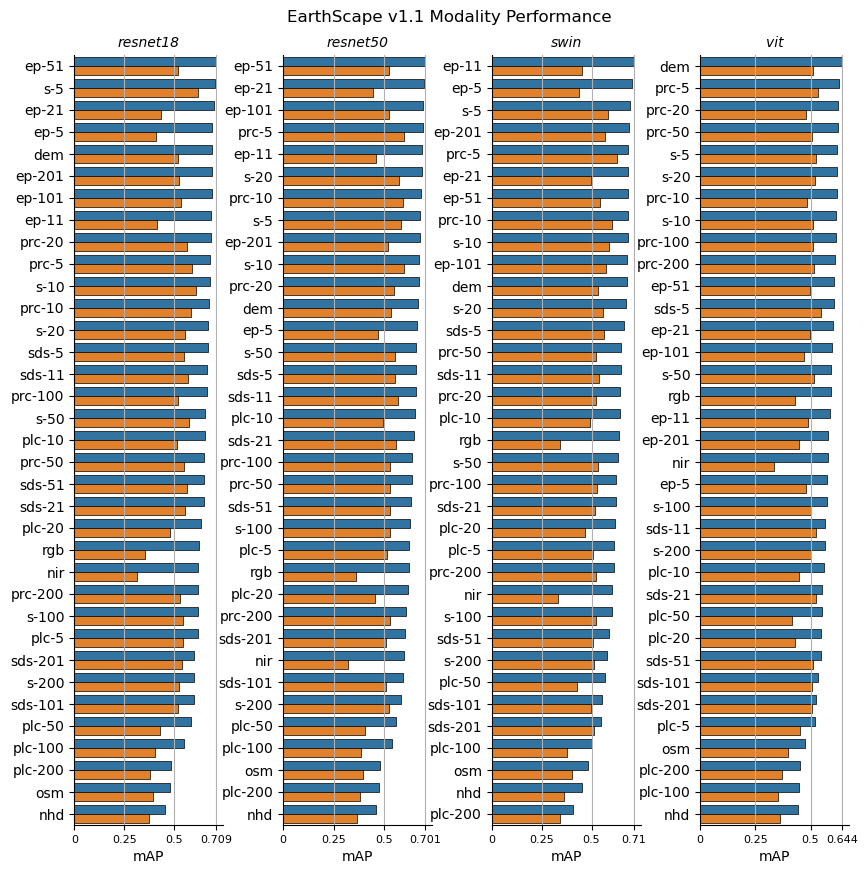

In [230]:
#############################################
# Modality Ranking Bar Charts
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'single_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# models to use...
models = ['resnet18', 'resnet50', 'swin', 'vit']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_single.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(2.5*len(models),10))
plt.subplots_adjust(wspace=0.4)
ax = ax.ravel()

idx = 0
for m in df_single['model'].unique():

    if m in [model.lower() for model in models]:

        df = df_single[df_single['model'] == m].copy()
        df.sort_values(f"macro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"macro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"macro_{metric} (id)", f"macro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}")
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Modality Performance", y=0.925)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

### Modality Rankings - All

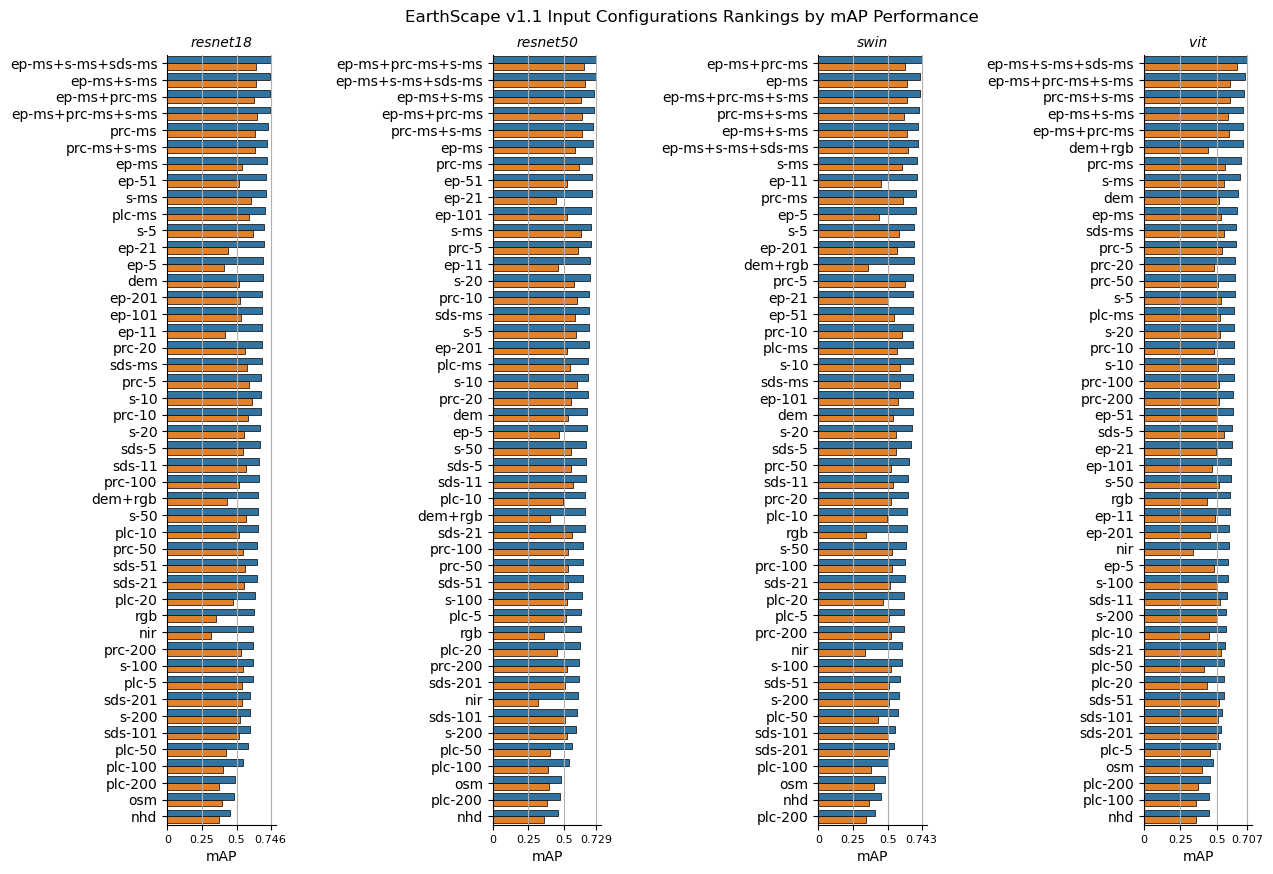

In [231]:
#############################################
# Modality Ranking Bar Charts
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'compiled_global.csv')
df_all = pd.read_csv(single_path)

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# models to use...
models = ['resnet18', 'resnet50', 'swin', 'vit']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_all.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(3.5*len(models),10))
plt.subplots_adjust(wspace=2)
ax = ax.ravel()

idx = 0
for m in df_all['model'].unique():

    if m in [model.lower() for model in models]:

        df = df_all[df_all['model'] == m].copy()
        df.sort_values(f"macro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"macro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"macro_{metric} (id)", f"macro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}")
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Input Configurations Rankings by {metric_label} Performance", y=0.925)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

### Scale Sensitivity

In [236]:
def parse_features(x):
    """Function to parse modality/input strings into modality family and ground sampling distance (GSD) or multi-scale (MS) configurations."""
    x_split = x.split('-')
    if len(x_split) == 1:
        return x_split[0], None
    elif len(x_split) == 2:
        return x_split[0], x_split[1]
    else:
        return 'multimodal', 'ms'
    

def spatial_support(x, bins, raw_gsd=5):
    """Function to group GSD features into families of effective area covered."""
    if x is not None:
        if str(x).isnumeric():
            for bin in bins:
                if np.isclose(int(x) * raw_gsd, bin, atol=10):
                    return bin
        else:
            return x
    else:
        return np.nan

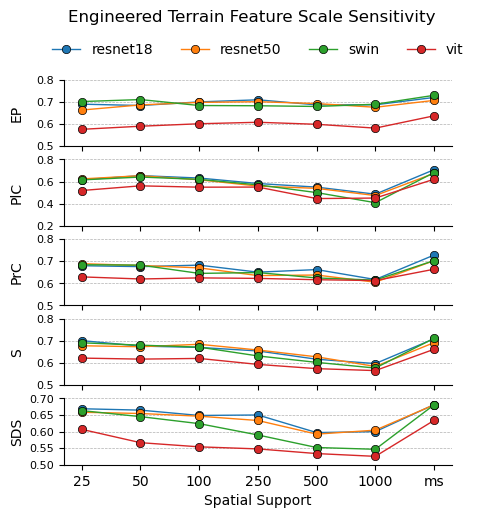

In [ ]:
#############################################
# Terrain Feature Scale-Sensitivity
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model'].unique():
        df = subset[subset['model'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"macro_{metric} (id)"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax[idx].set_ylabel(ylab)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].grid(True, axis='y', linestyle='--', linewidth=0.5)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xlabel('Spatial Support')
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle('Engineered Terrain Feature Scale Sensitivity', y=1.02)

# plot and save...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Cross-domain Performance

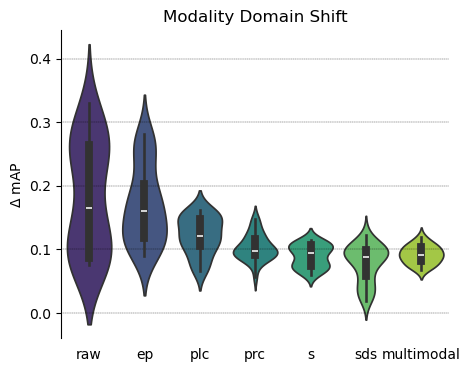

In [307]:
#############################################
# Cross-domain Performance - Violin Plots
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']

# output path for figure
output_path = os.path.join(assets_dir, 'cross_performance_violin.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled['delta map'] = df_compiled[f"macro_{metric} (id)"] - df_compiled[f"macro_{metric} (cd)"]


##### plot violin plots...
fig, ax = plt.subplots(figsize=(5,4))

# plot
inner_kws={'box_width':5, 'whis_width': 1, 'color':'k'}
sns.violinplot(data=df_compiled, y='delta map', x='family', hue='family', palette='viridis', order=family_order)

# customize...
ax.set_xlabel('')
ax.set_ylabel(r'$\Delta$ mAP')
ax.tick_params(bottom=False)
ax.grid(visible=True, axis='y', linestyle='--', linewidth=0.25, color='k')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_title('Modality Domain Shift')

# save & show...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()


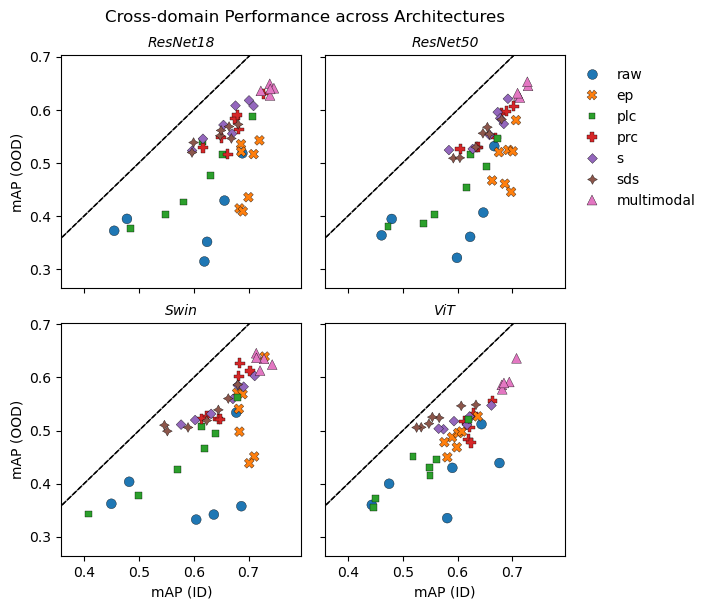

In [ ]:
#############################################
# Cross-domain Performance - Scatter Plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}

# output path for figure
output_path = os.path.join(assets_dir, 'cross_performance_scatter.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)


##### plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"macro_{metric} (id)"].min() - 0.05
xmax = df_compiled[f"macro_{metric} (id)"].max() + 0.05
ymin = df_compiled[f"macro_{metric} (cd)"].min() - 0.05
ymax = df_compiled[f"macro_{metric} (cd)"].max() + 0.05
lims = [(xmin, ymin),  (xmax, ymax)]

# iterate over model architectures...
models = df_compiled['model'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model'] == m].copy()

    # plot 1:1 line of perfect cross-region transfer...
    ax[idx].plot(lims, lims, 'k', linestyle='--', linewidth=1, zorder=1)

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"macro_{metric} (id)", y=f"macro_{metric} (cd)", hue='family', style='family', s=50, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(ymin, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ax[idx].set_ylabel(f"{metric_label} (OOD)")
    if 'resnet' in m:
        name = 'ResNet' + m[-2:]
        ax[idx].set_title(name, style='italic', fontsize=10)
    elif 'vit' in m:
        ax[idx].set_title('ViT', style='italic', fontsize=10)
    elif 'swin' in m:
        ax[idx].set_title('Swin', style='italic', fontsize=10)
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Cross-domain Performance across Architectures', y=0.95)

# save and show...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

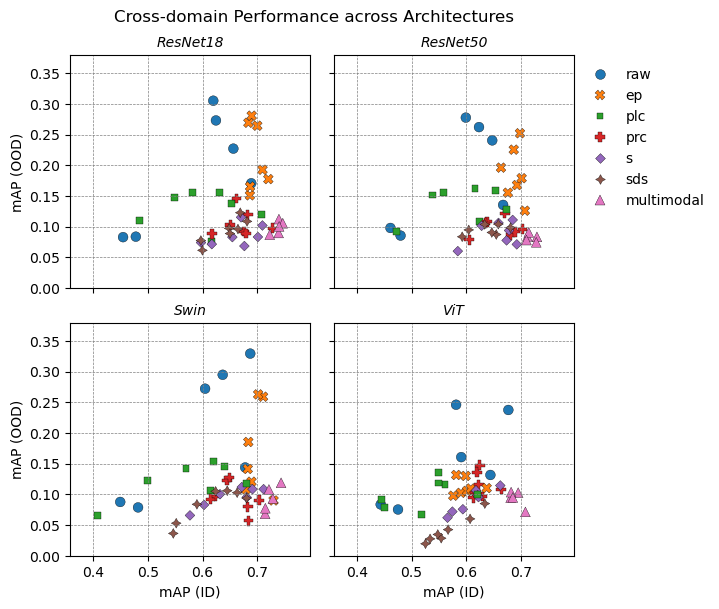

In [322]:
#############################################
# Cross-domain Performance - Delta Scatter plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']

# output path for figure
output_path = os.path.join(assets_dir, 'cross_performance_scatter_delta.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled[f"delta {metric}"] = df_compiled[f"macro_{metric} (id)"] - df_compiled[f"macro_{metric} (cd)"]


#### plot delta scatter plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"macro_{metric} (id)"].min() - 0.05
xmax = df_compiled[f"macro_{metric} (id)"].max() + 0.05
# ymin = df_compiled[f"macro_{metric} (cd)"].min() - 0.05
ymax = df_compiled[f"delta {metric}"].max() + 0.05
# lims = [(xmin, ymin),  (xmax, ymax)]

# iterate over model architectures...
models = df_compiled['model'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model'] == m].copy()

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"macro_{metric} (id)", y=f"delta {metric}", hue='family', style='family', s=50, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(0, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ax[idx].set_ylabel(f"{metric_label} (OOD)")
    if 'resnet' in m:
        name = 'ResNet' + m[-2:]
        ax[idx].set_title(name, style='italic', fontsize=10)
    elif 'vit' in m:
        ax[idx].set_title('ViT', style='italic', fontsize=10)
    elif 'swin' in m:
        ax[idx].set_title('Swin', style='italic', fontsize=10)
    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Cross-domain Performance across Architectures', y=0.95)

# save and show...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

# **Class-wise Performance**

## *Single Modality Experiments*

In [ ]:
##################################################
# Compile Class-wise Performance Metrics - Single
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'single_class.csv')


##### compile global in- & cross-domain data...
# initialize df
df_class = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in single_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_class = pd.concat([df_class, df], ignore_index=True, axis=0)
    df_class.loc[idx:idx+len(df), 'model'] = model_name
    df_class.loc[idx:idx+len(df), 'input'] = modalities
    df_class.loc[idx:idx+len(df), df_class.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_class.to_csv(output_path, index=False)
df_class.head(10)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem,af1,0.402417,571.0,538.0,0.622677,0.586690,0.604148,0.757856,0.703485,0.714193,435.0,567.0,0.291005,0.379310,0.329341,0.555249,0.341223,0.562500
1,resnet18,dem,Qal,0.335367,950.0,1010.0,0.776238,0.825263,0.800000,0.824415,0.895711,0.744792,845.0,1331.0,0.547708,0.862722,0.670037,0.484279,0.578969,0.532552
2,resnet18,dem,Qaf,0.058684,13.0,28.0,0.107143,0.230769,0.146341,0.880954,0.087856,0.977214,6.0,0.0,0.000000,0.000000,0.000000,0.685403,0.032778,0.996094
3,resnet18,dem,Qat,0.084915,61.0,210.0,0.228571,0.786885,0.354244,0.907730,0.308434,0.886068,77.0,2.0,0.000000,0.000000,0.000000,0.806103,0.162131,0.948568
4,resnet18,dem,Qc,0.378547,749.0,805.0,0.855901,0.919893,0.886744,0.962340,0.966037,0.885417,456.0,763.0,0.579292,0.969298,0.725185,0.945362,0.882790,0.781901
5,resnet18,dem,Qca,0.271758,432.0,514.0,0.686770,0.817130,0.746300,0.929933,0.864910,0.843750,249.0,242.0,0.636364,0.618474,0.627291,0.888371,0.634261,0.880859
6,resnet18,dem,Qr,0.387985,1433.0,1497.0,0.943220,0.985345,0.963823,0.930318,0.994803,0.930990,1511.0,1536.0,0.983724,1.000000,0.991795,0.803058,0.993830,0.983724
7,resnet18,ep-101,af1,0.142561,571.0,692.0,0.650289,0.788091,0.712589,0.841750,0.795029,0.763672,435.0,401.0,0.618454,0.570115,0.593301,0.784572,0.672870,0.778646
8,resnet18,ep-101,Qal,0.335206,950.0,1121.0,0.740410,0.873684,0.801545,0.809657,0.881219,0.732422,845.0,1304.0,0.587423,0.906509,0.712890,0.758936,0.818864,0.598307
9,resnet18,ep-101,Qaf,0.157042,13.0,32.0,0.093750,0.230769,0.133333,0.853376,0.085173,0.974609,6.0,7.0,0.000000,0.000000,0.000000,0.732244,0.010172,0.991536


## *Multi-scale Experiments*

In [10]:
##################################################
# Compile Class-wise Performance Metrics - Multiscale
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multiscale_class.csv')


##### compile global in- & cross-domain data...
# initialize df
df_class = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in ms_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_class = pd.concat([df_class, df], ignore_index=True, axis=0)
    df_class.loc[idx:idx+len(df), 'model'] = model_name
    df_class.loc[idx:idx+len(df), 'input'] = modalities
    df_class.loc[idx:idx+len(df), df_class.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_class.to_csv(output_path, index=False)
df_class.head(10)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,ep-ms,af1,0.166701,571.0,641.0,0.678627,0.761821,0.717822,0.852539,0.807584,0.777344,435.0,363.0,0.691460,0.577011,0.629073,0.799860,0.697051,0.807292
1,resnet18,ep-ms,Qal,0.560404,950.0,918.0,0.823529,0.795789,0.809422,0.844297,0.903840,0.768229,845.0,1058.0,0.663516,0.830769,0.737782,0.742563,0.781220,0.675130
2,resnet18,ep-ms,Qaf,0.061369,13.0,63.0,0.047619,0.230769,0.078947,0.889388,0.126165,0.954427,6.0,17.0,0.058824,0.166667,0.086957,0.752288,0.021241,0.986328
3,resnet18,ep-ms,Qat,0.441588,61.0,72.0,0.430556,0.508197,0.466165,0.910308,0.396106,0.953776,77.0,201.0,0.218905,0.571429,0.316547,0.864148,0.293067,0.876302
4,resnet18,ep-ms,Qc,0.464265,749.0,790.0,0.853165,0.899866,0.875893,0.957726,0.960449,0.875651,456.0,281.0,0.629893,0.388158,0.480326,0.744528,0.587996,0.750651
5,resnet18,ep-ms,Qca,0.457633,432.0,466.0,0.744635,0.803241,0.772829,0.933273,0.849968,0.867188,249.0,189.0,0.455026,0.345382,0.392694,0.796463,0.421057,0.826823
6,resnet18,ep-ms,Qr,0.447874,1433.0,1448.0,0.966160,0.976274,0.971191,0.939044,0.995225,0.945964,1511.0,1532.0,0.983681,0.997353,0.990470,0.813488,0.994926,0.981120
7,resnet18,plc-ms,af1,0.283573,571.0,620.0,0.651613,0.707531,0.678421,0.813658,0.758062,0.750651,435.0,590.0,0.474576,0.643678,0.546341,0.751695,0.591472,0.697266
8,resnet18,plc-ms,Qal,0.419322,950.0,1118.0,0.729875,0.858947,0.789168,0.802948,0.879762,0.716146,845.0,1371.0,0.572575,0.928994,0.708484,0.763288,0.828843,0.579427
9,resnet18,plc-ms,Qaf,0.049073,13.0,22.0,0.272727,0.461538,0.342857,0.913531,0.232252,0.985026,6.0,8.0,0.125000,0.166667,0.142857,0.840414,0.041318,0.992188


## *Multimodal Experiments*

## *Compilation*

In [12]:
##################################################
# Compile All Class-wise Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_class.csv")
ms_path = os.path.join(assets_dir, "multiscale_class.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_class.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))

df_global = pd.concat(df_list)
df_global.reset_index(drop=True, inplace=True)

df_global.to_csv(output_path, index=False)
df_global.head(10)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem,af1,0.402417,571.0,538.0,0.622677,0.586690,0.604148,0.757856,0.703485,0.714193,435.0,567.0,0.291005,0.379310,0.329341,0.555249,0.341223,0.562500
1,resnet18,dem,Qal,0.335367,950.0,1010.0,0.776238,0.825263,0.800000,0.824415,0.895711,0.744792,845.0,1331.0,0.547708,0.862722,0.670037,0.484279,0.578969,0.532552
2,resnet18,dem,Qaf,0.058684,13.0,28.0,0.107143,0.230769,0.146341,0.880954,0.087856,0.977214,6.0,0.0,0.000000,0.000000,0.000000,0.685403,0.032778,0.996094
3,resnet18,dem,Qat,0.084915,61.0,210.0,0.228571,0.786885,0.354244,0.907730,0.308434,0.886068,77.0,2.0,0.000000,0.000000,0.000000,0.806103,0.162131,0.948568
4,resnet18,dem,Qc,0.378547,749.0,805.0,0.855901,0.919893,0.886744,0.962340,0.966037,0.885417,456.0,763.0,0.579292,0.969298,0.725185,0.945362,0.882790,0.781901
5,resnet18,dem,Qca,0.271758,432.0,514.0,0.686770,0.817130,0.746300,0.929933,0.864910,0.843750,249.0,242.0,0.636364,0.618474,0.627291,0.888371,0.634261,0.880859
6,resnet18,dem,Qr,0.387985,1433.0,1497.0,0.943220,0.985345,0.963823,0.930318,0.994803,0.930990,1511.0,1536.0,0.983724,1.000000,0.991795,0.803058,0.993830,0.983724
7,resnet18,ep-101,af1,0.142561,571.0,692.0,0.650289,0.788091,0.712589,0.841750,0.795029,0.763672,435.0,401.0,0.618454,0.570115,0.593301,0.784572,0.672870,0.778646
8,resnet18,ep-101,Qal,0.335206,950.0,1121.0,0.740410,0.873684,0.801545,0.809657,0.881219,0.732422,845.0,1304.0,0.587423,0.906509,0.712890,0.758936,0.818864,0.598307
9,resnet18,ep-101,Qaf,0.157042,13.0,32.0,0.093750,0.230769,0.133333,0.853376,0.085173,0.974609,6.0,7.0,0.000000,0.000000,0.000000,0.732244,0.010172,0.991536


## *Visualizations*

### Class-wise Bar Plot

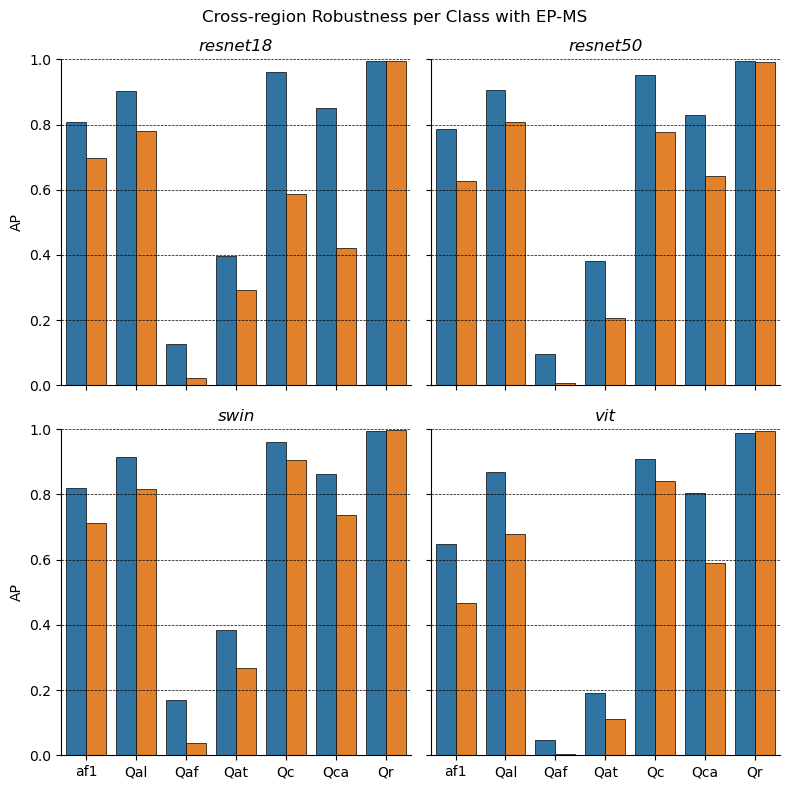

In [67]:

class_path = os.path.join(assets_dir, 'compiled_class.csv')
df_class = pd.read_csv(class_path)
modality = 'ep-ms'
metric = 'ap'

df = df_class[df_class['input'] == modality]


fig, ax = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(8,8))
ax = ax.ravel()

for idx, m in enumerate(df['model'].unique()):

    df2 = df[df['model'] == m]

    # reshape wide -> long
    plot_df = df2.melt(id_vars=['class'], value_vars=[f'{metric} (id)', f'{metric} (cd)'], var_name='domain', value_name=metric)

    sns.barplot(ax=ax[idx], data=plot_df, x='class', y=metric, hue='domain', linewidth=0.5, edgecolor='k', legend=False)

    ax[idx].set_title(m, style='italic')
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel(metric.upper())
    ax[idx].set_ylim(0,1)
    ax[idx].grid(visible=True, axis='y', linestyle='--', linewidth=0.5, color='k')
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)


plt.suptitle(f"Cross-region Robustness per Class with {modality.upper()}")
plt.tight_layout()
plt.show()


### Performance vs. Class-area Proportion